In [1]:
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.spatial.distance
import scipy.ndimage.filters
import copy
from matplotlib import animation
import matplotlib as mpl
from pylab import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.pyplot import cm
from matplotlib.cm import ScalarMappable
# Edit the font, font size, and axes width
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['lines.linewidth'] = 1.25

import matplotlib.font_manager as fm

font_dir = ['./fonts/helvetica/']
for font in fm.findSystemFonts(font_dir):
    fm.fontManager.addfont(font)
# Collect all the font names available to matplotlib
font_names = [f.name for f in fm.fontManager.ttflist]
#print(font_names)
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['xtick.major.pad']='1'
mpl.rcParams['ytick.major.pad']='1'

%matplotlib inline


In [2]:
workdir = '../fes/run_TOP'
figure_dir = 'figures'
data_dir = 'output'
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)
workdir

'../fes/run_TOP'

### Define Lennard Jones Potential

In [3]:
def LJ_V(r, epsilon, sigma, cutoff=None):
    """
    Calculates the Lennard-Jones potential energy between two particles.
    """
    og = 0.047 #original model parameters
    epsilon = epsilon/og
    if len(r) <= 0:
        return np.inf 
        
    s_over_r = sigma / r
    term12 = s_over_r**12
    term6 = s_over_r**6

    
    potential = 4 * epsilon * (term12 - term6)
   
    if cutoff is not None:
        idx_zero = np.where(r>=cutoff)[0]
        potential[idx_zero]=0
        
    return potential
    

In [4]:
sigma=0.38121 #same sigma for all models
eps_p = [0.047,0.036,0.025,0.0185] # epsilons are reduced by ~30 % each iteration
eps_w = [0.0257,0.01972,0.01369,0.01015]

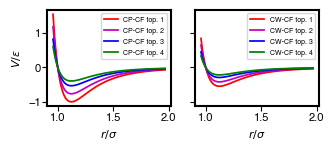

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(3.5,1.25), sharex=True,sharey=True)
lj_r = np.linspace(0.365,0.75,100)
top_color=['r','m','b','g']
for i in range(len(eps_p)):
    lj_p = LJ_V(lj_r, eps_p[i],sigma,cutoff=1.2)
    lj_w = LJ_V(lj_r, eps_w[i],sigma,cutoff=1.2)
    axs[0].plot(lj_r/sigma,lj_p, label=f'CP-CF top. {i+1}',color=top_color[i])
    axs[1].plot(lj_r/sigma,lj_w,  label=f'CW-CF top. {i+1}',color=top_color[i])
    axs[0].legend(fontsize=5)
    axs[1].legend(fontsize=5)
    axs[0].set_xlabel(r'$r/\sigma$')
    axs[0].set_ylabel(r"$V/\epsilon$")
    axs[1].set_xlabel(r'$r/\sigma$')
plt.savefig(F"{data_dir}/LJ_all.png")
plt.show()

### Read in colvar data

In [6]:
cv_data = {}
for i in range(1,5,1):
    if round(i,3) == -0.0:
        key = "0.0"
    else:
        key = str(round(i,3))
    cv_data[key]=[]


file_template = "/DIR_fes.colvar.out"
for k in cv_data:
    file_name = workdir.replace('TOP', k)+file_template
    for i in range(29,30):
        final_name = file_name.replace('DIR',str(i))
        dist = np.genfromtxt(final_name, comments='#', dtype=float)
        cv_data[k].append(dist)
    

### Plot kdeplot of distance  

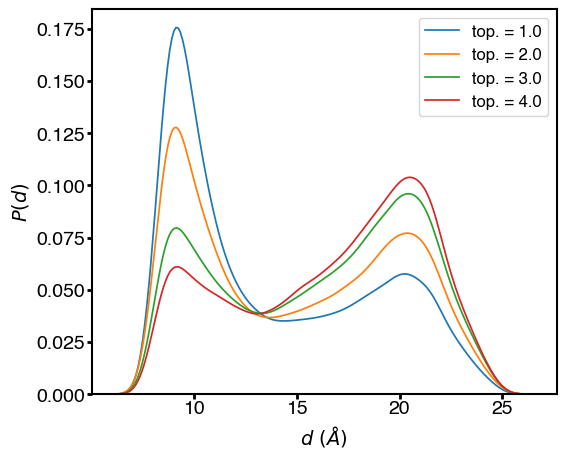

In [8]:
plt.figure(1,figsize=(6,5))
for key in cv_data:
    runs=cv_data[key]
    for i,run in enumerate(runs):
        sns.kdeplot(run[:,1], label='top. ='+ F" {np.abs(float(key))}",fill=False)
        plt.xlabel(r'$d \ (\AA)$', fontsize=14)
        plt.ylabel(r'$P(d) $', fontsize=14)
        plt.tick_params(axis='both', labelsize=14, width=2)
        plt.legend(fontsize=12)
plt.savefig(F"{data_dir}/DistanceDistribution{key}.png")
plt.show()

### Plot of Distance (d) vs time

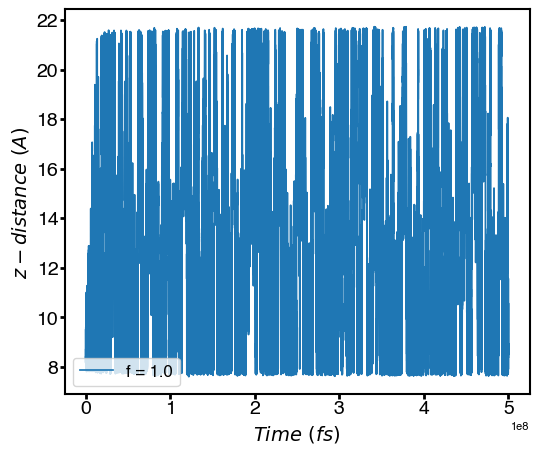

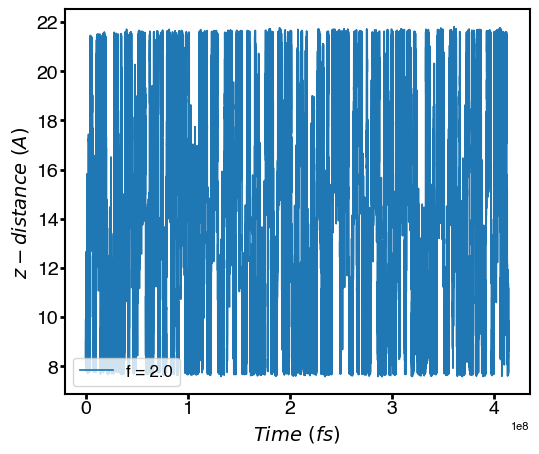

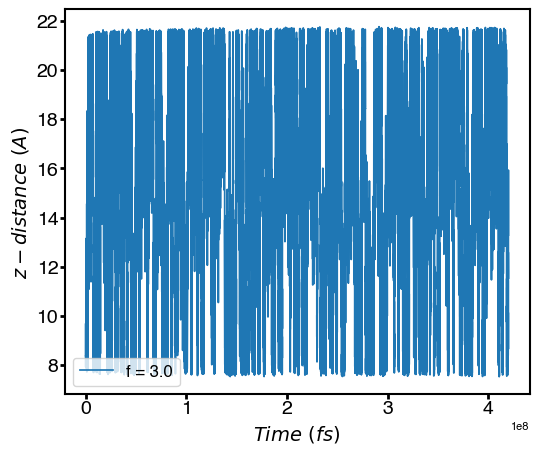

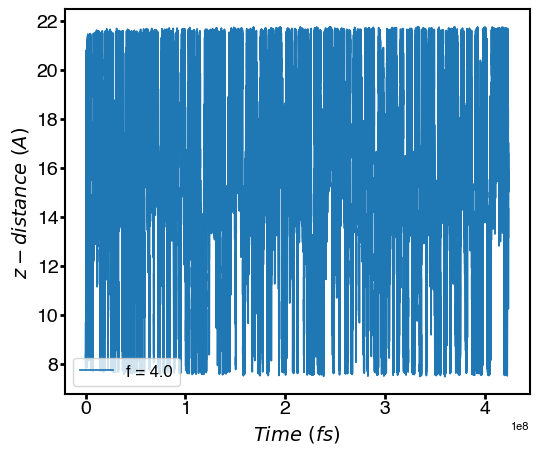

In [9]:
for key in cv_data:
    runs=cv_data[key]
    plt.figure(1, figsize=(6,5))
    for i,run in enumerate(runs):
        plt.plot(run[:,0],run[:,3], label='f ='+ F" {np.abs(float(key))}")
        plt.xlabel(r'$Time\ (fs) $', fontsize=14)
        plt.ylabel(r'$z-distance\ (A) $', fontsize=14)
        plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        plt.tick_params(axis='both', labelsize=14, width=2)
        plt.legend(fontsize=12,loc='lower left')
    plt.savefig(F"{data_dir}/DistanceVsTime{key}.png")
    plt.show()
    
    

### Plot z component and radial distance colvars 

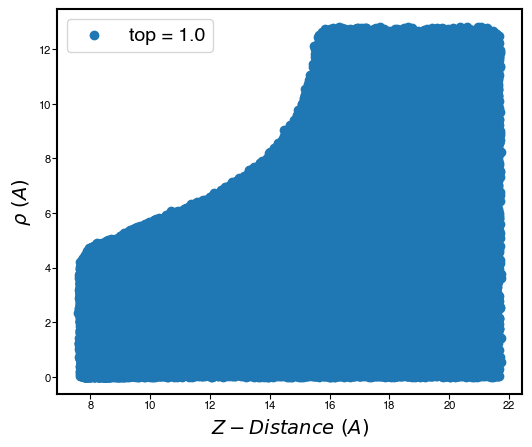

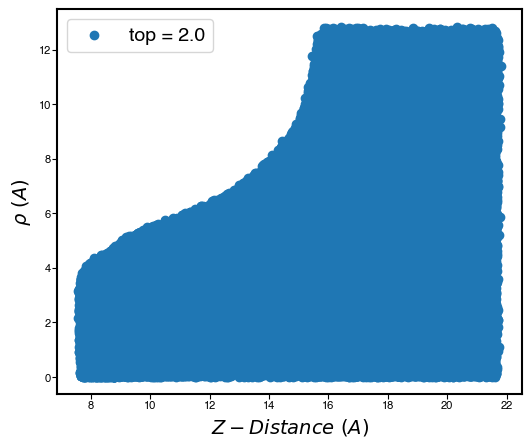

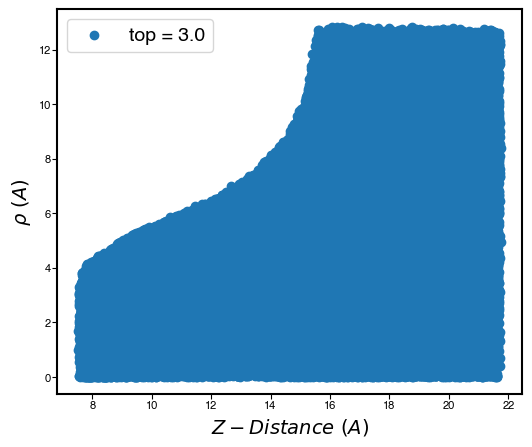

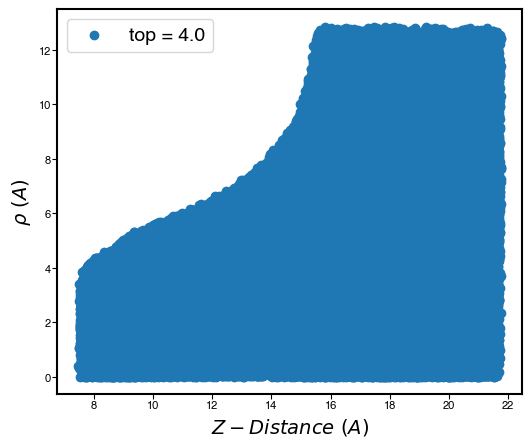

In [10]:
for key in cv_data:
    runs=cv_data[key]
    plt.figure(1, figsize=(6,5))
    for i,run in enumerate(runs):
        plt.scatter(run[:,3],run[:,2], label='top ='+ F" {np.abs(float(key))}")
        plt.xlabel(r'$Z-Distance\ (A) $', fontsize=14)
        plt.ylabel(r'${\rho}\ (A) $', fontsize=14)
        plt.legend(fontsize=14, loc='upper left')
    plt.savefig(data_dir+"/z_distanceVsRadial"+key+".png")
    plt.show()

#### Plot 2D FES 

In [11]:
fesr = {}
for i in range(1,5,1):
    if round(i,3) == -0.0:
        key = "0.0"
    else:
        key = str(round(i,3))
    fesr[key]=[]

file_template = "/DIR_fes.fes.dat"
for k in fesr:
    file_name = workdir.replace('TOP', k) + file_template
    for i in range(29,30):
        final_name = file_name.replace('DIR', str(i))
        #print(final_name)
        dist = np.genfromtxt(final_name, comments='#', dtype=float)
        fesr[k].append(dist)


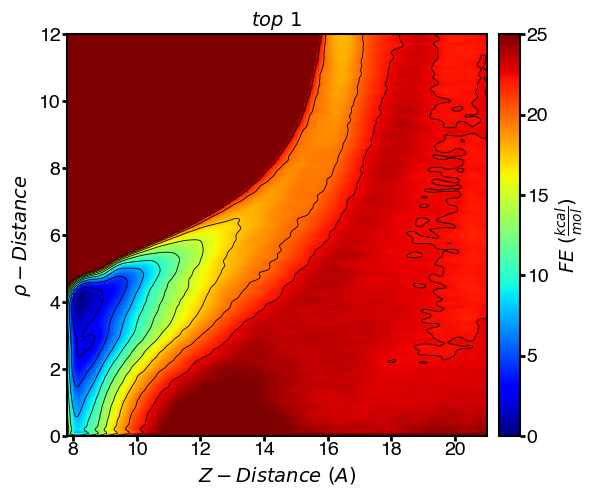

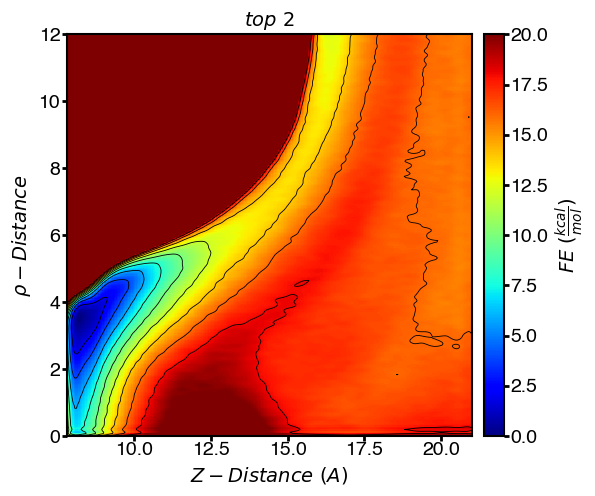

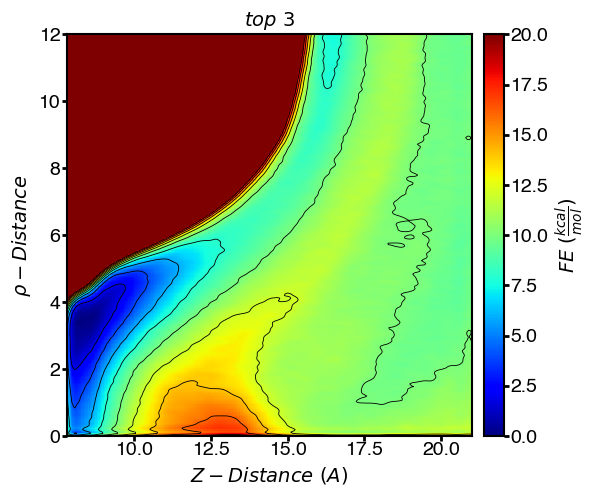

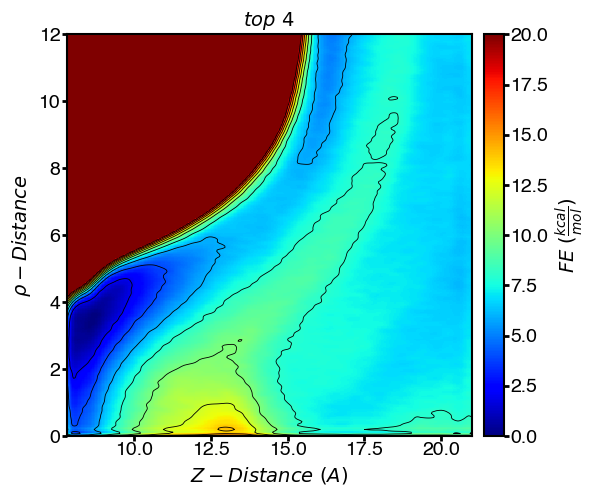

In [12]:

for key in fesr:
    runs=fesr[key]
    for i,run in enumerate(runs):
        fig, ax = plt.subplots(figsize=(6, 5))
        z = run[:,2]
        x = run[:,0]
        y = run[:,1]
        if key == '1':
            index=np.where((z>25))[0]
            z[index]=25
        else:
            index=np.where((z>20))[0]
            z[index]=20
            
        X = np.linspace(np.min(x),np.max(x), 301)
        Y = np.linspace(np.min(y), np.max(y), 301)
        XZ = z.reshape(301,301)
        ax.contour(X, Y, XZ, 9, colors='black', linewidths=0.6)
        im=ax.imshow(XZ,aspect='auto', origin='lower', interpolation='none', cmap='jet', extent = ( x.min(), x.max(), y.min(), y.max()))
        ax.set_title(rf"$top \ {key}$", size=14)
        ax.set_xlabel(r'$Z-Distance\ (A)$', size=14)
        ax.set_ylabel(r'${\rho}-Distance$', size=14)
        ax.set_xlim(7.8, 21.0)
        ax.tick_params(axis='both', labelsize=14, width=2)
        divider = make_axes_locatable(fig.gca())
        cax = divider.append_axes("right", "5%", pad="3%")
        cbar=plt.colorbar(im, cax=cax)
        cbar.set_label(r"$FE\ ({\frac{kcal}{mol}})$", size=14)
        plt.tick_params(axis='both', labelsize=14, width=2)
        plt.tight_layout()
        plt.savefig(data_dir+F"/ZandRhodistancevsFES_{key}.png")
        plt.show()

In [13]:

fesdz = {}
for i in range(1,5,1):
    if round(i,3) == -0.0:
        key = "0.0"
    else:
        key = str(round(i,3))
    fesdz[key]=[]

file_template = "/DIR_fes.dz3.dat"

for k in fesdz:
    file_name = workdir.replace('TOP', k) + file_template
    for i in range(29,30):
        final_name = file_name.replace('DIR', str(i))
        #print(final_name)
        dist = np.genfromtxt(final_name, comments='#', dtype=float)
        fesdz[k].append(dist)


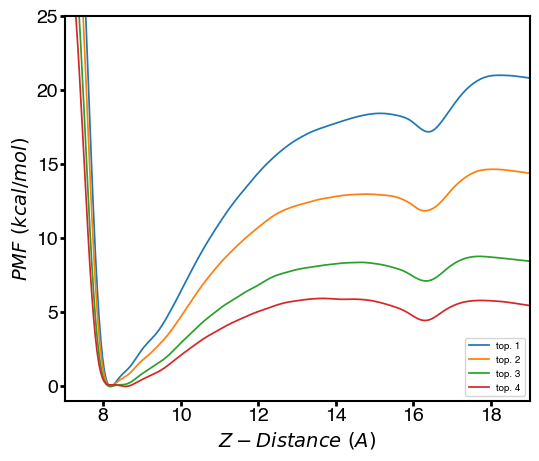

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
for i,key in enumerate(fesdz):
    runs=fesdz[key]
    for j,run in enumerate(runs):
        ax.plot(run[:,0], run[:,1],label=f"top. {key}")
        #ax.set_title(r"$$"), size=14)
        ax.set_ylabel(r'$PMF\ (kcal/mol)$',  size=14)
        ax.set_xlabel(r'$Z-Distance\ (A)$',  size=14)
        ax.set_xlim(7.0,19)
        ax.set_ylim(-1,25)
plt.tick_params(axis='both', labelsize=14, width=2)
plt.legend()
plt.savefig(F'{data_dir}/FES_distance-z_all.png')
plt.show()       
        

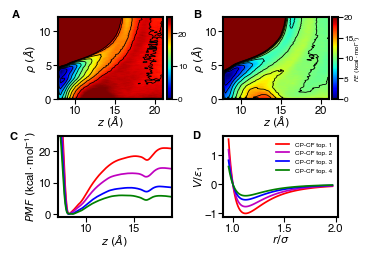

In [14]:
mpl.rcParams['font.size'] = 8
fig, ax = plt.subplots(2,2,figsize=(3.5,2.5))
ix,jx=0,0
runs=fesr['1']
for i,run in enumerate(runs):
    z = run[:,2]
    x = run[:,0]
    y = run[:,1]
    index=np.where((z>25))[0]
    z[index]=25

    X = np.linspace(np.min(x),np.max(x), 301)
    Y = np.linspace(np.min(y), np.max(y), 301)
    XZ = z.reshape(301,301)
    ax[ix,jx].contour(X, Y, XZ, 9, colors='black', linewidths=0.6)
    im=ax[ix,jx].imshow(XZ,aspect='auto', origin='lower', interpolation='none', cmap='jet', extent = ( x.min(), x.max(), y.min(), y.max()))
    #ax[ix,jx].set_title(rf"$top. \ 1$")
    ax[ix,jx].set_xlim(7.8, 21.0)
    ax[ix,jx].set_xlabel(r'$z\ (\AA)$', labelpad=-1)
    ax[ix,jx].set_ylabel(r'${\rho}\ (\AA)$', labelpad=1)
    #ax[ix,jx].set_yticks([i for i in range(38,49,2)])
    divider = make_axes_locatable(ax[ix,jx])
    cax2 = divider.append_axes("right", size="5%", pad=0.035)
    cbar=fig.colorbar(im, ax=ax[ix,jx], cax=cax2)
    cbar.ax.tick_params(labelsize=6, pad=1)
ax[ix,jx].text(2, 12, 'A', fontsize=8, fontweight='bold')


ix,jx=0,1
runs=fesr['3']
for i,run in enumerate(runs):
    z = run[:,2]
    x = run[:,0]
    y = run[:,1]
    index=np.where((z>20))[0]
    z[index]=20

    X = np.linspace(np.min(x),np.max(x), 301)
    Y = np.linspace(np.min(y), np.max(y), 301)
    XZ = z.reshape(301,301)
    ax[ix,jx].contour(X, Y, XZ, 9, colors='black', linewidths=0.6)
    im=ax[ix,jx].imshow(XZ,aspect='auto', origin='lower', interpolation='none', cmap='jet', extent = ( x.min(), x.max(), y.min(), y.max()))
    #ax[ix,jx].set_title(rf"$top. \ 1$")
    ax[ix,jx].set_xlim(7.8, 21.0)
    ax[ix,jx].set_xlabel(r'$z\ (\AA)$', labelpad=-1)
    ax[ix,jx].set_ylabel(r'${\rho}\ (\AA)$', labelpad=-1)
    #ax[ix,jx].set_yticks([i for i in range(38,49,2)])
    divider = make_axes_locatable(ax[ix,jx])
    cax2 = divider.append_axes("right", size="5%", pad=0.035)
    cbar=fig.colorbar(im, ax=ax[ix,jx], cax=cax2)
    cbar.ax.tick_params(labelsize=6, pad=1)
    cbar.set_label(r"$FE\ (\mathregular{kcal\cdot mol^{-1}})$", size=4.5,labelpad=0)
    
ax[ix,jx].text(4, 12, 'B', fontsize=8, fontweight='bold')

ix,jx=1,0
for i,key in enumerate(fesdz):
    runs=fesdz[key]
    for j,run in enumerate(runs):
        ax[ix,jx].plot(run[:,0], run[:,1],label=f"top. {key}", color=top_color[i])
        #ax.set_title(r"$$"), size=14)
        ax[ix,jx].set_ylabel(r'$PMF\ (\mathregular{kcal\cdot mol^{-1}})$', labelpad=1)
        ax[ix,jx].set_xlabel(r'$z\ (\AA)$', labelpad=-1  )
        ax[ix,jx].set_xlim(7.0,19)
        ax[ix,jx].set_ylim(-1,25)
ax[ix,jx].text(2, 24, 'C', fontsize=8, fontweight='bold')

ix,jx=1,1
for i in range(len(eps_p)):
    lj_p = LJ_V(lj_r, eps_p[i],sigma,cutoff=1.2)
    lj_w = LJ_V(lj_r, eps_w[i],sigma,cutoff=1.2)
    ax[ix,jx].plot(lj_r/sigma,lj_p, label=f'CP-CF top. {i+1}',color=top_color[i])
    #ax[ix,jx].plot(lj_r/sigma,lj_w,  label=f'CW-CF top. {i+1}',color=top_color[i])
    ax[ix,jx].legend(fontsize=4.65,ncol=1,frameon=False)
    #ax[1].legend(fontsize=5)
    ax[ix,jx].set_xlabel(r'$r/ \sigma$',labelpad=-1)
    ax[ix,jx].set_ylabel(r"$V/ {\epsilon_{\mathregular{1}}}$",labelpad=-1)
    #ax[i,j].set_xlabel(r'$r/\sigma$')

ax[ix,jx].text(0.6, 1.6, 'D', fontsize=8, fontweight='bold')


plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.45,hspace=0.45)
plt.savefig(f"{figure_dir}/weak_cavity_PMF1.pdf", bbox_inches='tight',format='pdf' )
plt.savefig(f"{figure_dir}/weak_cavity_PMF1.png", bbox_inches='tight',format='png' )
plt.show()

In [15]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

from matplotlib.patches import Rectangle

def get_legend_box_coord(ax, legend):
    """ Returns coordinates of the legend box """
    disp2data = ax.transData.inverted().transform
    box = legend.legendPatch
    # taken from here:
    # https://stackoverflow.com/a/28728709/4118756
    box_pixcoords = box.get_window_extent(ax)
    box_xycoords = [disp2data(box_pixcoords.p0), disp2data(box_pixcoords.p1)]
    box_xx, box_yy = np.array(box_xycoords).T
    return box_xx, box_yy

def draw_sublegend_box(ax, legend, idx):
    nitems = len(legend.legend_handles)
    xx, yy = get_legend_box_coord(ax, legend)
    # assuming equal spacing between legend items:
    y_divisors = np.linspace(*yy, num=nitems+1)
    height = y_divisors[idx]-y_divisors[idx+1]
    width = np.diff(xx)
    lower_left_xy = [xx[0], y_divisors[idx+1]]
    inv = ax.transAxes.inverted()
    bbox = legend.get_window_extent().transformed(inv)
    legend_box = Rectangle(
            xy = lower_left_xy,
            width = width,
            height = height,
            fill = False,
            transform=ax.transAxes,
            zorder = 10)
    print(legend_box)
    print(type(legend_box))
    ax.add_patch(legend_box)

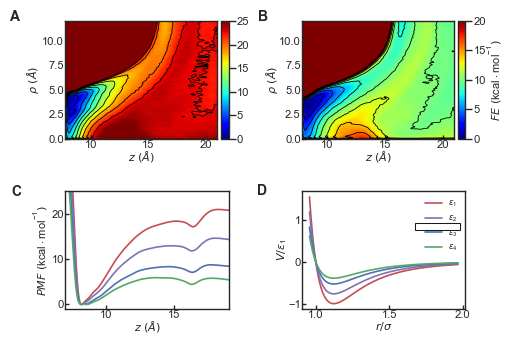

In [16]:
mpl.rcParams['font.size'] = 10
lfsize=10
fig, ax = plt.subplots(2,2,figsize=(5,3.6))
ix,jx=0,0
runs=fesr['1']
for i,run in enumerate(runs):
    z = run[:,2]
    x = run[:,0]
    y = run[:,1]
    index=np.where((z>25))[0]
    z[index]=25

    X = np.linspace(np.min(x),np.max(x), 301)
    Y = np.linspace(np.min(y), np.max(y), 301)
    XZ = z.reshape(301,301)
    ax[ix,jx].contour(X, Y, XZ, 9, colors='black', linewidths=0.6)
    im=ax[ix,jx].imshow(XZ,aspect='auto', origin='lower', interpolation='none', cmap='jet', extent = ( x.min(), x.max(), y.min(), y.max()))
    #ax[ix,jx].set_title(rf"$top. \ 1$")
    ax[ix,jx].set_xlim(7.8, 21.0)
    ax[ix,jx].set_xlabel(r'$z\ (\AA)$', labelpad=-1)
    ax[ix,jx].set_ylabel(r'${\rho}\ (\AA)$', labelpad=1)
    #ax[ix,jx].set_yticks([i for i in range(38,49,2)])
    divider = make_axes_locatable(ax[ix,jx])
    cax2 = divider.append_axes("right", size="5%", pad=0.035)
    cbar=fig.colorbar(im, ax=ax[ix,jx], cax=cax2)
    cbar.ax.tick_params(labelsize=8, pad=1)
ax[ix,jx].text(3, 12, 'A', fontsize=lfsize, fontweight='bold')


ix,jx=0,1
runs=fesr['3']
for i,run in enumerate(runs):
    z = run[:,2]
    x = run[:,0]
    y = run[:,1]
    index=np.where((z>20))[0]
    z[index]=20

    X = np.linspace(np.min(x),np.max(x), 301)
    Y = np.linspace(np.min(y), np.max(y), 301)
    XZ = z.reshape(301,301)
    ax[ix,jx].contour(X, Y, XZ, 9, colors='black', linewidths=0.6)
    im=ax[ix,jx].imshow(XZ,aspect='auto', origin='lower', interpolation='none', cmap='jet', extent = ( x.min(), x.max(), y.min(), y.max()))
    #ax[ix,jx].set_title(rf"$top. \ 1$")
    ax[ix,jx].set_xlim(7.8, 21.0)
    ax[ix,jx].set_xlabel(r'$z\ (\AA)$', labelpad=-1)
    ax[ix,jx].set_ylabel(r'${\rho}\ (\AA)$', labelpad=-1)
    #ax[ix,jx].set_yticks([i for i in range(38,49,2)])
    divider = make_axes_locatable(ax[ix,jx])
    cax2 = divider.append_axes("right", size="5%", pad=0.035)
    cbar=fig.colorbar(im, ax=ax[ix,jx], cax=cax2)
    cbar.ax.tick_params(labelsize=8, pad=1)
    cbar.set_label(r"$FE\ (\mathregular{kcal\cdot mol^{-1}})$", size=8,labelpad=0)
    
ax[ix,jx].text(4, 12, 'B', fontsize=lfsize, fontweight='bold')

ix,jx=1,0
for i,key in enumerate(fesdz):
    runs=fesdz[key]
    for j,run in enumerate(runs):
        ax[ix,jx].plot(run[:,0], run[:,1],label=f"top. {key}", color=top_color[i])
        #ax.set_title(r"$$"), size=14)
        ax[ix,jx].set_ylabel(r'$PMF\ (\mathregular{kcal\cdot mol^{-1}})$', labelpad=1)
        ax[ix,jx].set_xlabel(r'$z\ (\AA)$', labelpad=-1  )
        ax[ix,jx].set_xlim(7.0,19)
        ax[ix,jx].set_ylim(-1,25)
ax[ix,jx].text(3, 24, 'C', fontsize=lfsize, fontweight='bold')

ix,jx=1,1
for i in range(len(eps_p)):
    lj_p = LJ_V(lj_r, eps_p[i],sigma,cutoff=1.2)
    lj_w = LJ_V(lj_r, eps_w[i],sigma,cutoff=1.2)
    ax[ix,jx].plot(lj_r/sigma,lj_p, label=r"$\epsilon_{\mathregular{%d}}$"%(i+1),color=top_color[i])
    #ax[ix,jx].plot(lj_r/sigma,lj_w,  label=f'CW-CF top. {i+1}',color=top_color[i])
    #ax[ix,jx].legend(fontsize=6,ncol=1,frameon=False)
    #ax[1].legend(fontsize=5)
    ax[ix,jx].set_xlabel(r'$r/ \sigma$',labelpad=0)
    ax[ix,jx].set_ylabel(r"$V/ {\epsilon_{\mathregular{1}}}$",labelpad=-1)
    #ax[i,j].set_xlabel(r'$r/\sigma$')

legend=ax[ix,jx].legend(fontsize=6,ncol=1,frameon=False)
target_handle = legend.legend_handles[3] 

# 4. Get the bounding box of the target handle in the appropriate transform
# We get the bounding box of the target handle in 'display' coordinates (pixels)
# and convert it to 'figure' coordinates for placing the rectangle
bbox = target_handle.get_window_extent().transformed(fig.transFigure.inverted())

# 5. Add the Rectangle to the figure (or axes with correct transform)
# Define the rectangle using the bbox coordinates and transform
# We can adjust width/height slightly if needed
rect = Rectangle((.8, 0.32), 0.089, 0.02,
                         transform=fig.transFigure, # Use figure transform
                         linewidth=0.75, edgecolor='k', facecolor='none', 
                         zorder=10) # Ensure it's above other elements

# Add the rectangle to the figure
fig.add_artist(rect)


ax[ix,jx].text(0.6, 1.6, 'D', fontsize=lfsize, fontweight='bold')

for axi in ax.flatten():
    axi.tick_params(axis='both', direction='in', which='both', length=3)

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.45,hspace=0.45)
plt.savefig(f"{figure_dir}/weak_cavity_PMF_l.pdf", bbox_inches='tight',format='pdf' )
plt.savefig(f"{figure_dir}/weak_cavity_PMF_l.png", bbox_inches='tight',format='png' )
plt.show()